Research Question or Organizational Need

For this project, the organizational need that was solved was whether the e-commerce company should implement a new webpage to increase user conversion rate. The research question that was answered for this project was: Will a new webpage for the e-commerce website result in a higher number of converted users compared to the current webpage?

Part I - Data Cleaning and Preparation

In [89]:
# Import the necessary libraries 
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [90]:
# Import the dataset 
df = pd.read_csv('ab_data.csv')

In [91]:
# Provide preview of dataset 
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [92]:
# Drop unnecessary columns 
columns_to_drop = ['user_id', 'timestamp', 'landing_page']
df.drop(columns=columns_to_drop, inplace=True)

In [93]:
# Ensure that columns were dropped 
df.head()

,group,converted
0,control,0
1,control,0
2,treatment,0
3,treatment,0
4,control,1


In [94]:
# Calculate total number of rows
total_rows = len(df)
print('Number of rows:', total_rows)

Number of rows: 294478


In [95]:
# Identify any missing values 
miss_values = df.isnull().sum()
total_miss_values = miss_values.sum()
if total_miss_values == 0: 
    print('No missing data values.')

No missing data values.


In [96]:
# Check column data type
noncat = df.dtypes
print(noncat)

group        object
converted     int64
dtype: object


In [97]:
# Check values of converted column
conv_col_values = df['converted'].unique().tolist()
print('List of possible values in the converted column:', conv_col_values)

List of possible values in the converted column: [0, 1]


In [98]:
# Check percent of users in control group
users_in_control = df['group'].value_counts()['control'] / total_rows
print('Percent of users in the control group:', users_in_control * 100, '%')

Percent of users in the control group: 49.987435394155085 %


In [99]:
# Check percent of users in treatment group
users_in_treat = df['group'].value_counts()['treatment'] / total_rows
print('Percent of users in the treatment group:', users_in_treat * 100, '%')

Percent of users in the treatment group: 50.01256460584492 %


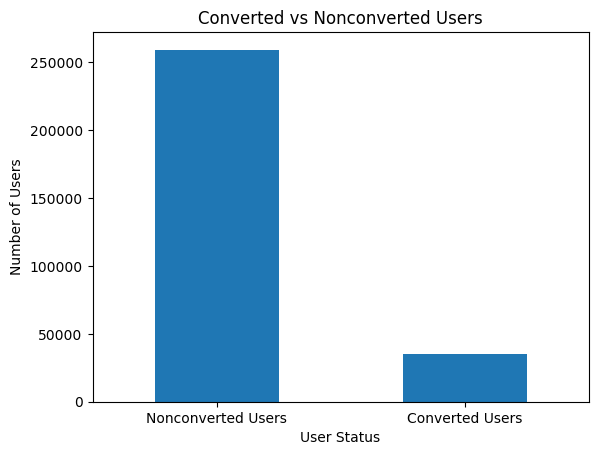

In [100]:
# Plot graph with total number converted/non-converted users
conversion = df['converted'].value_counts()

df['converted'].value_counts().plot(kind='bar');
plt.title('Converted vs Nonconverted Users');
plt.xticks(
    range(len(conversion)), ['Nonconverted Users', 'Converted Users'], rotation=0)
plt.xlabel('User Status')
plt.ylabel('Number of Users');
plt.show();

Part II - Descriptive Statistical Methods

In [101]:
# Calculate probability of converted user
conv_prob = df['converted'].mean()
print('Probability that the user converted regardless of page:', conv_prob * 100, '%')

Probability that the user converted regardless of page: 11.96591935560551 %


In [102]:
# Calculate probability of nonconverted user 
conv_prob_not_converted = 1 - df['converted'].mean()
print('Probability that the user did not convert regardless of page', conv_prob_not_converted * 100, '%')

Probability that the user did not convert regardless of page 88.03408064439449 %


In [103]:
# Calculate probability of converted user in control group 
cont_conv_prob = df.query('group == "control"')['converted'].mean()
print('Probability that a user in the control group converted:', cont_conv_prob *100, '%')

Probability that a user in the control group converted: 12.039917935897611 %


In [104]:
# Calculate probability of converted user in treatment group 
treat_conv_prob = df.query('group == "treatment"')['converted'].mean()
print('Probability that a user in the treatment group converted:', treat_conv_prob *100, '%')

Probability that a user in the treatment group converted: 11.891957956489856 %


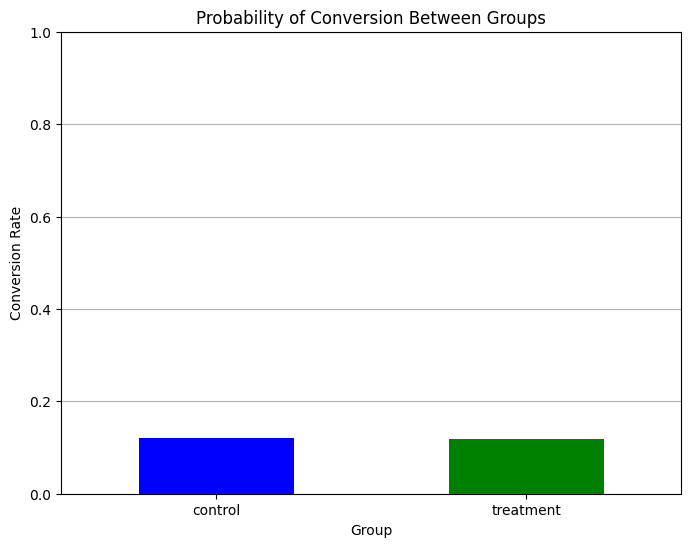

In [105]:
# Plot probability of user conversion for each group
conversion_rates = df.groupby('group')['converted'].mean()
plt.figure(figsize=(8, 6))
conversion_rates.plot(kind='bar', color=['blue', 'green'])
plt.title('Probability of Conversion Between Groups')
plt.xlabel('Group')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=0)
plt.ylim(0, 1)  # Setting y-axis limit to 0-1 for proportion
plt.grid(axis='y')

# Display the plot
plt.show()

Do you see evidence that the treatment is related to higher `converted` rates?

In [106]:
if treat_conv_prob > cont_conv_prob: 
    print('Yes')
else:
    print('No')

No


Part III - Logistic Regression

Null hypothesis: The new webpage will not result in more converted users compared to the 
existing webpage. 

Alternative hypothesis: The new webpage will result in more converted users compared to the existing webpage. 

p-value < 0.05 - Reject the null hypothesis 

p_value > 0.05 - Accept the null hypothesis 

In [109]:
# Create intercept column 
df['intercept'] = 1

# Create ab_page column with dummy variable
df['ab_page'] = pd.get_dummies(df['group'])['treatment']

In [110]:
# Check that columns were added 
df.head()

,group,converted,intercept,ab_page
0,control,0,1,0
1,control,0,1,0
2,treatment,0,1,1
3,treatment,0,1,1
4,control,1,1,0


In [112]:
# Select the features (X) and target variable (y)
X = df[['intercept', 'ab_page']]
y = df['converted']

In [113]:
# Logit Model
logit_mod = sm.Logit(y, X)
logit_res = logit_mod.fit()

Optimization terminated successfully.
         Current function value: 0.366243
         Iterations 6


In [114]:
# Print summary of logistic regression model's results
print(logit_res.summary())

                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:               294478
Model:                          Logit   Df Residuals:                   294476
Method:                           MLE   Df Model:                            1
Date:                Sat, 22 Jun 2024   Pseudo R-squ.:               7.093e-06
Time:                        14:29:55   Log-Likelihood:            -1.0785e+05
converged:                       True   LL-Null:                   -1.0785e+05
Covariance Type:            nonrobust   LLR p-value:                    0.2161
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -1.9887      0.008   -248.297      0.000      -2.004      -1.973
ab_page       -0.0140      0.011     -1.237      0.216      -0.036       0.008


Since the p-value of the ab_page is 0.216, we accept the null hypothesis, which means that 
the new webpage did not result in more converted users compared to the existing webpage. 

In [3]:
jupyter nbconvert --to pdf capstone.ipynb

SyntaxError: invalid syntax (2029313376.py, line 1)